In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
def set_seed(seed=42):
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
DATA_DIR = "/content"
train_npz = np.load(f"{DATA_DIR}/quickdraw_train.npz")
test_npz  = np.load(f"{DATA_DIR}/quickdraw_test.npz")

x = train_npz["x_train"]
y = train_npz["y_train"]
class_names = train_npz["class_names"]
x_test = test_npz["test_images"]
num_classes = len(class_names)
input_dim = x.shape[1]

print("x:", x.shape, "y:", y.shape, "classes:", num_classes)
print("x_test:", x_test.shape)
print("class_names:", class_names)
x = (x.astype(np.float32) / 255.0)
x_test = (x_test.astype(np.float32) / 255.0)
y = y.astype(np.int64)
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.15, random_state=42, stratify=y
)
Xtr = torch.from_numpy(x_train)
Ytr = torch.from_numpy(y_train)
Xva = torch.from_numpy(x_val)
Yva = torch.from_numpy(y_val)
Xte = torch.from_numpy(x_test)

train_ds = TensorDataset(Xtr, Ytr)
val_ds   = TensorDataset(Xva, Yva)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

x: (60000, 784) y: (60000,) classes: 15
x_test: (15000, 784)
class_names: ['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']
Train batches: 200 Val batches: 36


In [11]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct = 0, 0
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

def fit(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=0.0, max_epochs=40):
    assert epochs <= max_epochs, "Epoch constraint violated (must be <= 40)."
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   []
    }

    best_val_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        total, correct = 0, 0
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        sched.step()

        tr_loss = total_loss / total
        tr_acc  = correct / total
        va_loss, va_acc = evaluate(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

TASK A: PANCAKE MODEL

In [12]:
class PancakeMLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, width=1024, num_hidden=2, dropout=0.2):
        super().__init__()
        assert num_hidden in [1, 2], "Part A should be 1 or 2 hidden layers."

        layers = []
        in_dim = input_dim

        for i in range(num_hidden):
            layers.append(nn.Linear(in_dim, width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = width

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
pancake = PancakeMLP(input_dim=input_dim, num_classes=num_classes, width=1024, num_hidden=2, dropout=0.2)
print("Pancake params:", count_params(pancake))

Pancake params: 1868815


In [13]:
EPOCHS_A = 25
LR_A = 1e-3
WD_A = 1e-4

pancake_trained, hist_A = fit(
    pancake,
    train_loader,
    val_loader,
    epochs=EPOCHS_A,
    lr=LR_A,
    weight_decay=WD_A
)
print("Best-ish (restored) Val Acc:", evaluate(pancake_trained, val_loader)[1])
torch.save(pancake_trained.state_dict(), "pancake_partA.pt")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/25 | train loss 1.2108 acc 0.6048 | val loss 0.9547 acc 0.6893
Epoch 02/25 | train loss 0.8756 acc 0.7119 | val loss 0.8661 acc 0.7178
Epoch 03/25 | train loss 0.7554 acc 0.7515 | val loss 0.8018 acc 0.7308
Epoch 04/25 | train loss 0.6600 acc 0.7824 | val loss 0.7363 acc 0.7596
Epoch 05/25 | train loss 0.5830 acc 0.8040 | val loss 0.7217 acc 0.7662
Epoch 06/25 | train loss 0.5113 acc 0.8268 | val loss 0.7067 acc 0.7733
Epoch 07/25 | train loss 0.4513 acc 0.8460 | val loss 0.7363 acc 0.7674
Epoch 08/25 | train loss 0.3890 acc 0.8663 | val loss 0.7623 acc 0.7656
Epoch 09/25 | train loss 0.3393 acc 0.8832 | val loss 0.7680 acc 0.7722
Epoch 10/25 | train loss 0.2915 acc 0.8999 | val loss 0.7827 acc 0.7683
Epoch 11/25 | train loss 0.2385 acc 0.9167 | val loss 0.8169 acc 0.7750
Epoch 12/25 | train loss 0.2033 acc 0.9304 | val loss 0.8484 acc 0.7781
Epoch 13/25 | train loss 0.1686 acc 0.9425 | val loss 0.8833 acc 0.7716
Epoch 14/25 | train loss 0.1443 acc 0.9510 | val loss 0.8956 acc

TASK 2: Tower Model

In [14]:
class TowerMLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, width=256, depth=6, dropout=0.1, act="relu"):
        super().__init__()
        assert depth >= 5, "Part B requires 5 or more hidden layers."
        if act == "relu":
            Act = nn.ReLU
        elif act == "leakyrelu":
            Act = lambda: nn.LeakyReLU(0.1)
        elif act == "gelu":
            Act = nn.GELU
        else:
            raise ValueError("act must be one of: relu, leakyrelu, gelu")

        layers = []
        in_dim = input_dim
        for i in range(depth):
            layers.append(nn.Linear(in_dim, width))
            layers.append(nn.BatchNorm1d(width))
            layers.append(Act())
            layers.append(nn.Dropout(dropout))
            in_dim = width

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

tower = TowerMLP(input_dim=input_dim, num_classes=num_classes, width=256, depth=6, dropout=0.15, act="leakyrelu")
print("Tower params:", count_params(tower))

Tower params: 536847


In [15]:
EPOCHS_B = 30
LR_B = 8e-4
WD_B = 2e-4
tower_trained, hist_B = fit(
    tower,
    train_loader,
    val_loader,
    epochs=EPOCHS_B,
    lr=LR_B,
    weight_decay=WD_B
)
print("Best-ish (restored) Val Acc:", evaluate(tower_trained, val_loader)[1])
torch.save(tower_trained.state_dict(), "tower_partB.pt")

Epoch 01/30 | train loss 1.4497 acc 0.5195 | val loss 0.9872 acc 0.6686
Epoch 02/30 | train loss 1.0443 acc 0.6521 | val loss 0.8698 acc 0.7076
Epoch 03/30 | train loss 0.9384 acc 0.6865 | val loss 0.8282 acc 0.7258
Epoch 04/30 | train loss 0.8718 acc 0.7080 | val loss 0.7951 acc 0.7348
Epoch 05/30 | train loss 0.8283 acc 0.7216 | val loss 0.7847 acc 0.7383
Epoch 06/30 | train loss 0.7897 acc 0.7347 | val loss 0.7588 acc 0.7489
Epoch 07/30 | train loss 0.7518 acc 0.7467 | val loss 0.7413 acc 0.7507
Epoch 08/30 | train loss 0.7197 acc 0.7592 | val loss 0.7320 acc 0.7593
Epoch 09/30 | train loss 0.6952 acc 0.7672 | val loss 0.7365 acc 0.7572
Epoch 10/30 | train loss 0.6683 acc 0.7756 | val loss 0.7150 acc 0.7656
Epoch 11/30 | train loss 0.6433 acc 0.7835 | val loss 0.7191 acc 0.7637
Epoch 12/30 | train loss 0.6232 acc 0.7921 | val loss 0.7109 acc 0.7661
Epoch 13/30 | train loss 0.6046 acc 0.7975 | val loss 0.7049 acc 0.7720
Epoch 14/30 | train loss 0.5811 acc 0.8059 | val loss 0.6981 acc

In [16]:
def summarize_run(name, model, hist, save_plot=True):
    tr_loss, tr_acc = evaluate(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    print(f"[{name}] params={count_params(model):,}")
    print(f"  Train: loss={tr_loss:.4f} acc={tr_acc:.4f}")
    print(f"  Val:   loss={va_loss:.4f} acc={va_acc:.4f}")
    print(f"  Best Val Acc (tracked): {max(hist['val_acc']):.4f}")
    print("-" * 60)

    epochs = range(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist["train_loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name} - Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(epochs, hist["train_acc"], label="Train Accuracy")
    plt.plot(epochs, hist["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{name} - Accuracy Curve")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    if save_plot:
        os.makedirs("saved_plots", exist_ok=True)
        plot_path = f"saved_plots/{name.replace(' ','_')}.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Plot saved to → {plot_path}")

    plt.show()

[Part A Pancake] params=1,868,815
  Train: loss=0.0155 acc=0.9985
  Val:   loss=1.0411 acc=0.7798
  Best Val Acc (tracked): 0.7798
------------------------------------------------------------
Plot saved to → saved_plots/Part_A_Pancake.png


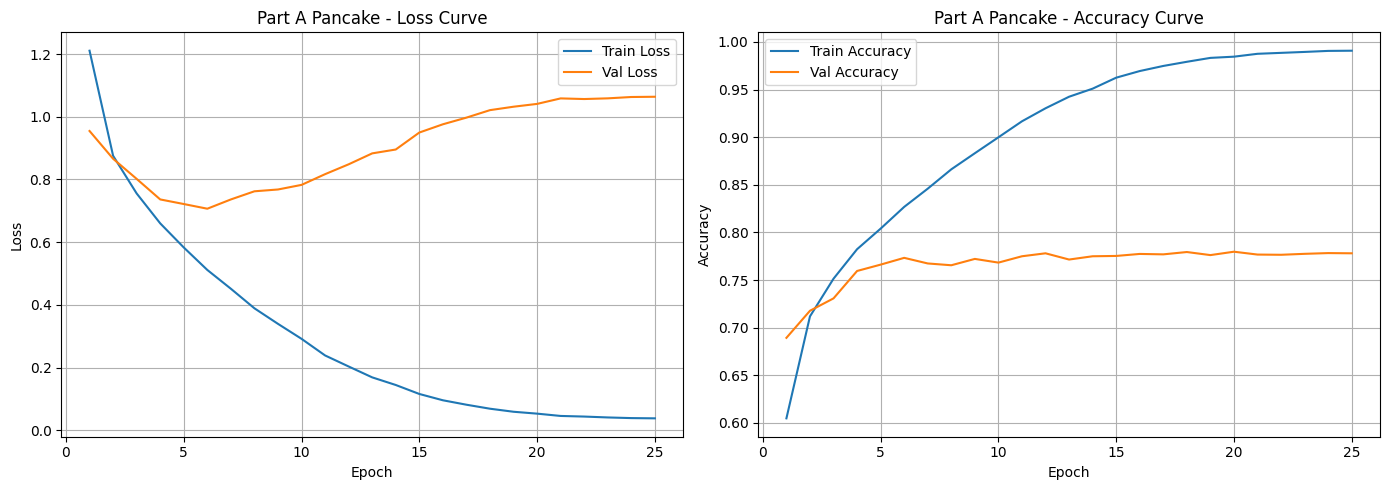

[Part B Tower] params=536,847
  Train: loss=0.2805 acc=0.9093
  Val:   loss=0.7057 acc=0.7843
  Best Val Acc (tracked): 0.7843
------------------------------------------------------------
Plot saved to → saved_plots/Part_B_Tower.png


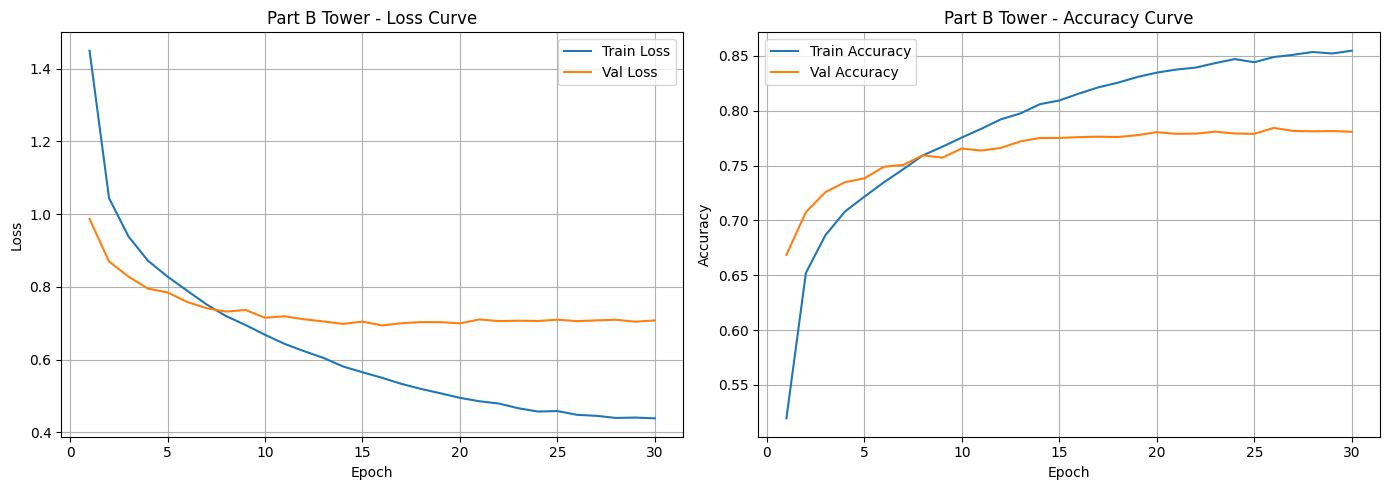

In [18]:
summarize_run("Part A Pancake", pancake_trained, hist_A)
summarize_run("Part B Tower", tower_trained, hist_B)

In [19]:
##OPTIMIZED 1
import math

def mixup_batch(x, y, alpha=0.2):
    """Returns mixed inputs, pairs of targets, and lambda."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    x_mix = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return x_mix, y_a, y_b, lam

def mixup_loss(logits, y_a, y_b, lam, label_smoothing=0.0):
    loss_a = F.cross_entropy(logits, y_a, label_smoothing=label_smoothing)
    loss_b = F.cross_entropy(logits, y_b, label_smoothing=label_smoothing)
    return lam * loss_a + (1 - lam) * loss_b

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct = 0, 0
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

def fit_champion(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr_max=2e-3,
    weight_decay=1e-4,
    label_smoothing=0.0,
    mixup_alpha=0.0,
    grad_clip=1.0,
    max_epochs=40
):
    assert epochs <= max_epochs, "Epoch constraint violated (must be <= 40)."
    model = model.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr_max, weight_decay=weight_decay)

    steps_per_epoch = len(train_loader)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=lr_max,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e3
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        total, correct, total_loss = 0, 0, 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            if mixup_alpha > 0:
                xb, y_a, y_b, lam = mixup_batch(xb, yb, alpha=mixup_alpha)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)

            if mixup_alpha > 0:
                loss = mixup_loss(logits, y_a, y_b, lam, label_smoothing=label_smoothing)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
            else:
                loss = F.cross_entropy(logits, yb, label_smoothing=label_smoothing)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()

            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            sched.step()

            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        tr_loss = total_loss / total
        tr_acc  = correct / total
        va_loss, va_acc = evaluate(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [20]:
import os
import json

def save_model_and_history(model, history, model_name):
    os.makedirs("saved_models", exist_ok=True)

    model_path = f"saved_models/{model_name}.pt"
    history_path = f"saved_models/{model_name}_history.json"
    torch.save(model.state_dict(), model_path)
    history_clean = {
        k: [float(v) for v in vals]
        for k, vals in history.items()
    }

    with open(history_path, "w") as f:
        json.dump(history_clean, f, indent=4)

    print(f"Saved model to: {model_path}")
    print(f"Saved history to: {history_path}")

M1 params: 1202703
Epoch 01/35 | train loss 1.6419 acc 0.5570 | val loss 0.9469 acc 0.7013
Epoch 02/35 | train loss 1.2222 acc 0.7023 | val loss 0.8598 acc 0.7228
Epoch 03/35 | train loss 1.1324 acc 0.7396 | val loss 0.7906 acc 0.7458
Epoch 04/35 | train loss 1.0545 acc 0.7720 | val loss 0.7179 acc 0.7760
Epoch 05/35 | train loss 0.9839 acc 0.8034 | val loss 0.6947 acc 0.7834
Epoch 06/35 | train loss 0.9297 acc 0.8236 | val loss 0.6665 acc 0.7911
Epoch 07/35 | train loss 0.8815 acc 0.8438 | val loss 0.6817 acc 0.7852
Epoch 08/35 | train loss 0.8427 acc 0.8607 | val loss 0.6605 acc 0.7943
Epoch 09/35 | train loss 0.8013 acc 0.8786 | val loss 0.6750 acc 0.7884
Epoch 10/35 | train loss 0.7644 acc 0.8951 | val loss 0.6637 acc 0.7939
Epoch 11/35 | train loss 0.7348 acc 0.9075 | val loss 0.6935 acc 0.7906
Epoch 12/35 | train loss 0.7079 acc 0.9175 | val loss 0.6776 acc 0.7988
Epoch 13/35 | train loss 0.6812 acc 0.9317 | val loss 0.6911 acc 0.7971
Epoch 14/35 | train loss 0.6569 acc 0.9423 | 

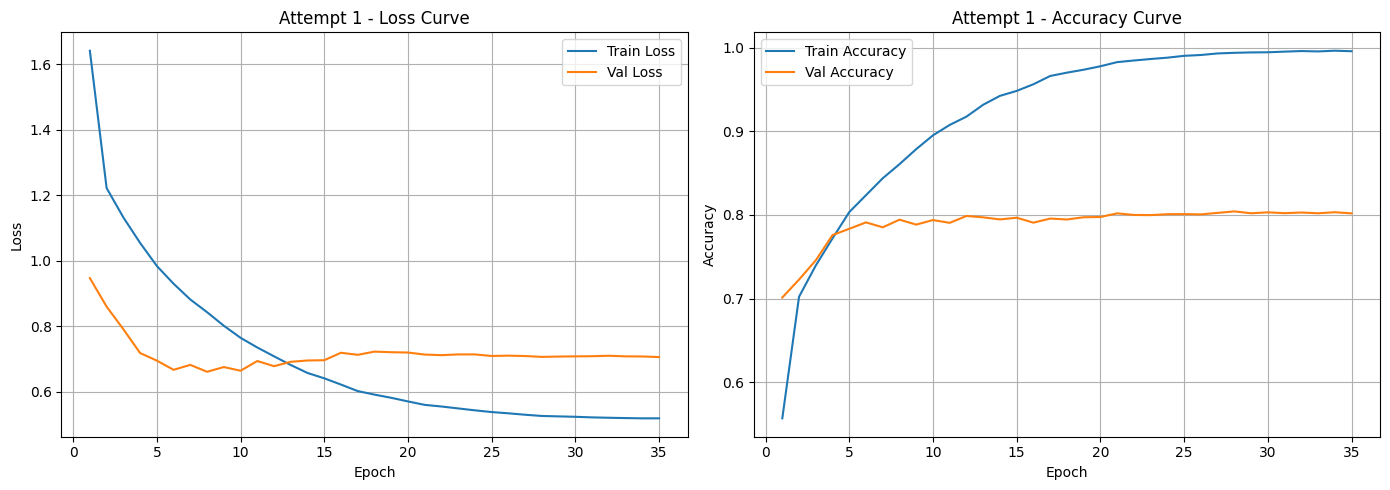

In [21]:
class BN_GELU_MLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, widths=(768, 512, 384), dropout=0.25):
        super().__init__()
        layers = []
        in_dim = input_dim
        for w in widths:
            layers += [nn.Linear(in_dim, w), nn.BatchNorm1d(w), nn.GELU(), nn.Dropout(dropout)]
            in_dim = w
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

m1 = BN_GELU_MLP(input_dim=input_dim, num_classes=num_classes)
print("M1 params:", count_params(m1))

m1_trained, hist_m1 = fit_champion(
    m1, train_loader, val_loader,
    epochs=35,
    lr_max=2.5e-3,
    weight_decay=2e-4,
    label_smoothing=0.08,
    mixup_alpha=0.0,
    grad_clip=1.0
)

val_acc_m1 = evaluate(m1_trained, val_loader)[1]
print("M1 val acc:", val_acc_m1)

save_model_and_history(m1_trained, hist_m1, "model1_bn_gelu")
summarize_run("Attempt 1", m1_trained, hist_m1)

In [22]:
class LN_SiLU_MLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, widths=(1024, 512, 256), in_dropout=0.15, dropout=0.25):
        super().__init__()
        self.in_drop = nn.Dropout(in_dropout)

        layers = []
        in_dim = input_dim
        for w in widths:
            layers += [nn.Linear(in_dim, w), nn.LayerNorm(w), nn.SiLU(), nn.Dropout(dropout)]
            in_dim = w
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.in_drop(x)
        return self.net(x)

m2 = LN_SiLU_MLP(input_dim=input_dim, num_classes=num_classes)
print("M2 params:", count_params(m2))

m2_trained, hist_m2 = fit_champion(
    m2, train_loader, val_loader,
    epochs=35,
    lr_max=2.0e-3,
    weight_decay=3e-4,
    label_smoothing=0.06,
    mixup_alpha=0.0,
    grad_clip=1.0
)

val_acc_m2 = evaluate(m2_trained, val_loader)[1]
print("M2 val acc:", val_acc_m2)

save_model_and_history(m2_trained, hist_m2, "model2_ln_silu")
summarize_run("Attempt 2", m2_trained, hist_m2)

M2 params: 1467407
Epoch 01/35 | train loss 1.7470 acc 0.4942 | val loss 1.0783 acc 0.6462
Epoch 02/35 | train loss 1.2969 acc 0.6409 | val loss 1.0339 acc 0.6649
Epoch 03/35 | train loss 1.2208 acc 0.6699 | val loss 0.9373 acc 0.6907
Epoch 04/35 | train loss 1.1358 acc 0.7040 | val loss 0.8346 acc 0.7306
Epoch 05/35 | train loss 1.0712 acc 0.7280 | val loss 0.8135 acc 0.7313
Epoch 06/35 | train loss 1.0228 acc 0.7499 | val loss 0.7404 acc 0.7593
Epoch 07/35 | train loss 0.9832 acc 0.7634 | val loss 0.7193 acc 0.7757
Epoch 08/35 | train loss 0.9520 acc 0.7765 | val loss 0.7027 acc 0.7770
Epoch 09/35 | train loss 0.9256 acc 0.7870 | val loss 0.7022 acc 0.7711
Epoch 10/35 | train loss 0.8984 acc 0.7974 | val loss 0.7036 acc 0.7736
Epoch 11/35 | train loss 0.8733 acc 0.8077 | val loss 0.6803 acc 0.7800
Epoch 12/35 | train loss 0.8523 acc 0.8172 | val loss 0.6763 acc 0.7856
Epoch 13/35 | train loss 0.8318 acc 0.8249 | val loss 0.6586 acc 0.7862
Epoch 14/35 | train loss 0.8129 acc 0.8292 | 

M3 params: 2125071


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/35 | train loss 1.9112 acc 0.2964 | val loss 1.0428 acc 0.6737
Epoch 02/35 | train loss 1.4950 acc 0.3185 | val loss 0.9510 acc 0.6988
Epoch 03/35 | train loss 1.4155 acc 0.3879 | val loss 0.8945 acc 0.7162
Epoch 04/35 | train loss 1.3711 acc 0.3994 | val loss 0.8043 acc 0.7529
Epoch 05/35 | train loss 1.3133 acc 0.3971 | val loss 0.7893 acc 0.7631
Epoch 06/35 | train loss 1.2699 acc 0.4244 | val loss 0.7690 acc 0.7629
Epoch 07/35 | train loss 1.2547 acc 0.4242 | val loss 0.7292 acc 0.7803
Epoch 08/35 | train loss 1.2520 acc 0.4342 | val loss 0.7328 acc 0.7770
Epoch 09/35 | train loss 1.2240 acc 0.4546 | val loss 0.7227 acc 0.7833
Epoch 10/35 | train loss 1.1658 acc 0.4858 | val loss 0.7210 acc 0.7892
Epoch 11/35 | train loss 1.1606 acc 0.4580 | val loss 0.7174 acc 0.7879
Epoch 12/35 | train loss 1.1790 acc 0.4450 | val loss 0.7214 acc 0.7870
Epoch 13/35 | train loss 1.0919 acc 0.4375 | val loss 0.7288 acc 0.7838
Epoch 14/35 | train loss 1.0978 acc 0.4329 | val loss 0.7388 acc

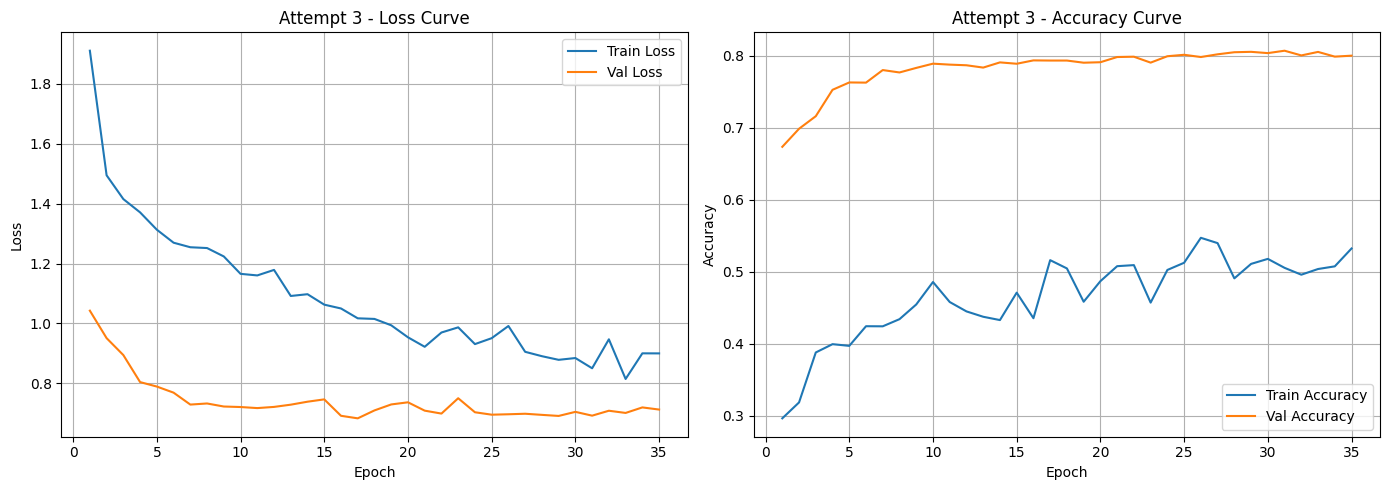

In [23]:
class PyramidBNMLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, widths=(1024, 768, 512, 256), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for w in widths:
            layers += [nn.Linear(in_dim, w), nn.BatchNorm1d(w), nn.LeakyReLU(0.1), nn.Dropout(dropout)]
            in_dim = w
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

m3 = PyramidBNMLP(input_dim=input_dim, num_classes=num_classes)
print("M3 params:", count_params(m3))

m3_trained, hist_m3 = fit_champion(
    m3, train_loader, val_loader,
    epochs=35,
    lr_max=2.0e-3,
    weight_decay=4e-4,
    label_smoothing=0.10,
    mixup_alpha=0.10,
    grad_clip=1.0
)

val_acc_m3 = evaluate(m3_trained, val_loader)[1]
print("M3 val acc:", val_acc_m3)

save_model_and_history(m3_trained, hist_m3, "model3_pyramid_bn")
summarize_run("Attempt 3", m3_trained, hist_m3)

M5 params: 980175
Epoch 01/40 | train loss 2.7758 acc 0.1152 | val loss 1.8340 acc 0.3812
Epoch 02/40 | train loss 1.9190 acc 0.2767 | val loss 1.0513 acc 0.6571
Epoch 03/40 | train loss 1.5816 acc 0.3283 | val loss 0.9619 acc 0.6926
Epoch 04/40 | train loss 1.5088 acc 0.4031 | val loss 0.8552 acc 0.7319
Epoch 05/40 | train loss 1.4274 acc 0.4084 | val loss 0.8685 acc 0.7361
Epoch 06/40 | train loss 1.3816 acc 0.3559 | val loss 0.8051 acc 0.7496
Epoch 07/40 | train loss 1.4273 acc 0.4275 | val loss 0.8031 acc 0.7562
Epoch 08/40 | train loss 1.3745 acc 0.3780 | val loss 0.8220 acc 0.7514
Epoch 09/40 | train loss 1.3551 acc 0.3926 | val loss 0.7913 acc 0.7719
Epoch 10/40 | train loss 1.2876 acc 0.3959 | val loss 0.7499 acc 0.7777
Epoch 11/40 | train loss 1.3163 acc 0.3828 | val loss 0.7629 acc 0.7824
Epoch 12/40 | train loss 1.1991 acc 0.4297 | val loss 0.7337 acc 0.7768
Epoch 13/40 | train loss 1.2616 acc 0.4627 | val loss 0.7398 acc 0.7850
Epoch 14/40 | train loss 1.2081 acc 0.4647 | v

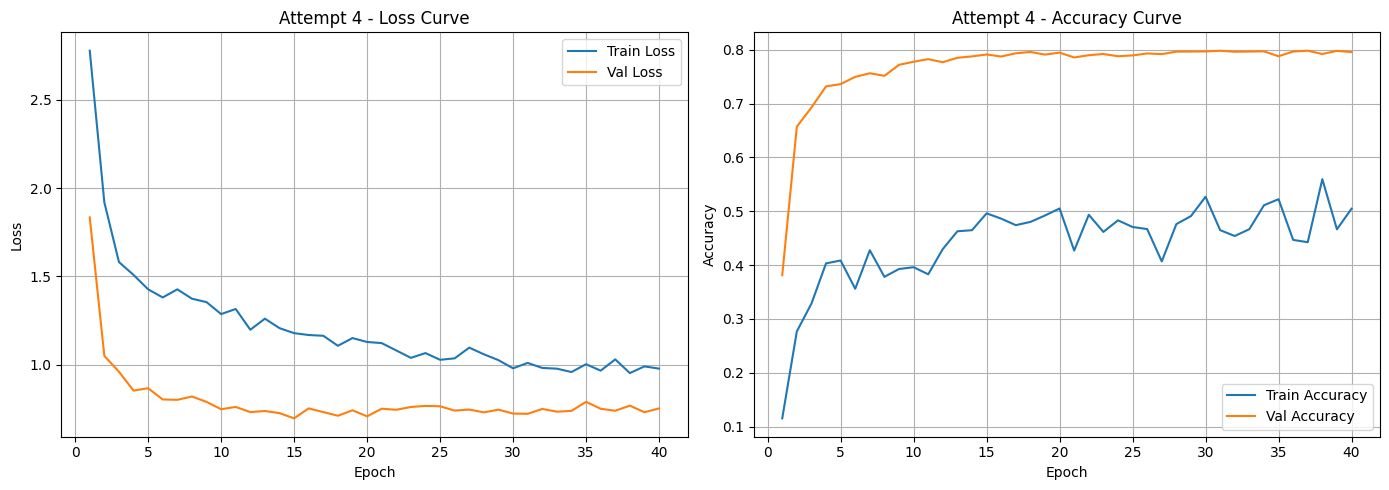

In [24]:
class DeepTowerV2(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, width=320, depth=8, dropout=0.18):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(depth):
            layers += [nn.Linear(in_dim, width), nn.BatchNorm1d(width), nn.GELU(), nn.Dropout(dropout)]
            in_dim = width
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)

m5 = DeepTowerV2(input_dim=input_dim, num_classes=num_classes, width=320, depth=8, dropout=0.18)
print("M5 params:", count_params(m5))

m5_trained, hist_m5 = fit_champion(
    m5, train_loader, val_loader,
    epochs=40,
    lr_max=1.8e-3,
    weight_decay=3e-4,
    label_smoothing=0.08,
    mixup_alpha=0.20,
    grad_clip=1.0
)

val_acc_m5 = evaluate(m5_trained, val_loader)[1]
print("M5 val acc:", val_acc_m5)

save_model_and_history(m5_trained, hist_m5, "model5_deeptower_v2")
summarize_run("Attempt 4", m5_trained, hist_m5)

OTHER ATTEMPTS WITH DATA AUGMENTATION

In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class QuickDrawAugDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train
        self.tf_train = T.Compose([
            T.ToPILImage(),
            T.RandomAffine(
                degrees=12,
                translate=(0.10, 0.10),
                scale=(0.90, 1.10),
                shear=8
            ),
            T.ToTensor(),
            T.RandomErasing(p=0.35, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0.0),
        ])

        self.tf_eval = T.Compose([
            T.ToTensor()
        ])

    def __len__(self): return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        img = (x.reshape(28,28) * 255).astype(np.uint8)
        if self.train:
            t = self.tf_train(img)
            t = (t + 0.02 * torch.randn_like(t)).clamp(0, 1)
        else:
            t = self.tf_eval(img)
        x_flat = t.view(-1)
        if self.y is None:
            return x_flat
        return x_flat, int(self.y[idx])
BATCH_SIZE = 256
train_aug_ds = QuickDrawAugDataset(x_train, y_train, train=True)
val_aug_ds   = QuickDrawAugDataset(x_val,   y_val,   train=False)

train_loader = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_aug_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Augmented train/val loaders ready.")

Augmented train/val loaders ready.


In [26]:
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    for xb, yb in loader:
        xb = xb.to(device); yb = yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def fit_champion_swa(
    model,
    train_loader,
    val_loader,
    epochs=35,
    lr=2e-3,
    weight_decay=2e-4,
    label_smoothing=0.08,
    mixup_alpha=0.2,
    grad_clip=1.0,
    swa_start=0.65,
    max_epochs=40
):
    assert epochs <= max_epochs, "Epoch constraint violated (<=40)."
    model = model.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    base_sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    swa_model = AveragedModel(model)
    swa_begin = int(epochs * swa_start)
    swa_sched = SWALR(opt, swa_lr=lr * 0.2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val = -1.0
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total, correct, total_loss = 0, 0, 0.0

        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)

            xb, y_a, y_b, lam = mixup_batch(xb, yb, alpha=mixup_alpha)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)

            loss_a = F.cross_entropy(logits, y_a, label_smoothing=label_smoothing)
            loss_b = F.cross_entropy(logits, y_b, label_smoothing=label_smoothing)
            loss = lam*loss_a + (1-lam)*loss_b

            loss.backward()
            if grad_clip and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()  # proxy under mixup
            total += xb.size(0)

        if ep >= swa_begin:
            swa_model.update_parameters(model)
            swa_sched.step()
        else:
            base_sched.step()

        tr_loss = total_loss/total
        tr_acc  = correct/total
        va_loss, va_acc = evaluate(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    if epochs >= swa_begin + 2:
        swa_model = swa_model.to(device)
        update_bn(train_loader, swa_model)
        return swa_model, history
    model.load_state_dict(best_state)
    return model, history

In [27]:
class ResBlockSmall(nn.Module):
    def __init__(self, dim, dropout=0.12):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim*2)
        self.fc2 = nn.Linear(dim*2, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = self.ln(x)
        h = F.gelu(self.fc1(h))
        h = self.drop(h)
        h = self.fc2(h)
        return x + self.drop(h)

class ResidualMLP_Small(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, dim=256, blocks=6, dropout=0.12):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(input_dim, dim), nn.GELU(), nn.Dropout(dropout))
        self.blocks = nn.Sequential(*[ResBlockSmall(dim, dropout=dropout) for _ in range(blocks)])
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)

mC1 = ResidualMLP_Small(input_dim=input_dim, num_classes=num_classes, dim=256, blocks=6, dropout=0.12)
print("C1 params:", count_params(mC1))

mC1_trained, hist_C1 = fit_champion_swa(
    mC1, train_loader, val_loader,
    epochs=40, lr=2.2e-3, weight_decay=2e-4,
    label_smoothing=0.10, mixup_alpha=0.25,
    grad_clip=1.0, swa_start=0.60
)
print("C1 val acc:", evaluate(mC1_trained, val_loader)[1])
summarize_run("Attempt 5", mC1_trained, hist_C1)

C1 params: 1785871
Epoch 01/40 | train loss 2.1611 acc 0.2224 | val loss 1.4286 acc 0.5143
Epoch 02/40 | train loss 1.8566 acc 0.2666 | val loss 1.1531 acc 0.6296
Epoch 03/40 | train loss 1.8123 acc 0.3106 | val loss 1.0746 acc 0.6552
Epoch 04/40 | train loss 1.7863 acc 0.3281 | val loss 0.9719 acc 0.6826
Epoch 05/40 | train loss 1.7581 acc 0.3160 | val loss 0.9850 acc 0.6886
Epoch 06/40 | train loss 1.6682 acc 0.3275 | val loss 0.9159 acc 0.7090
Epoch 07/40 | train loss 1.7048 acc 0.3084 | val loss 0.8644 acc 0.7292
Epoch 08/40 | train loss 1.6646 acc 0.3445 | val loss 0.8383 acc 0.7380
Epoch 09/40 | train loss 1.6842 acc 0.3382 | val loss 0.8861 acc 0.7422
Epoch 10/40 | train loss 1.6676 acc 0.3646 | val loss 0.8170 acc 0.7412
Epoch 11/40 | train loss 1.6357 acc 0.3244 | val loss 0.8061 acc 0.7567
Epoch 12/40 | train loss 1.5960 acc 0.3758 | val loss 0.8321 acc 0.7522
Epoch 13/40 | train loss 1.6024 acc 0.3722 | val loss 0.8170 acc 0.7522
Epoch 14/40 | train loss 1.5559 acc 0.3814 | 

C5 params: 1289615
Epoch 01/40 | train loss 2.0700 acc 0.2745 | val loss 1.1421 acc 0.6293
Epoch 02/40 | train loss 1.8926 acc 0.3131 | val loss 1.1157 acc 0.6521
Epoch 03/40 | train loss 1.7920 acc 0.3201 | val loss 1.0589 acc 0.6920
Epoch 04/40 | train loss 1.7576 acc 0.2975 | val loss 1.0923 acc 0.6933
Epoch 05/40 | train loss 1.6913 acc 0.3320 | val loss 1.0105 acc 0.7094
Epoch 06/40 | train loss 1.7039 acc 0.3312 | val loss 0.9974 acc 0.7134
Epoch 07/40 | train loss 1.6730 acc 0.3755 | val loss 0.9201 acc 0.7413
Epoch 08/40 | train loss 1.6312 acc 0.3399 | val loss 0.9086 acc 0.7353
Epoch 09/40 | train loss 1.6200 acc 0.3249 | val loss 0.8637 acc 0.7559
Epoch 10/40 | train loss 1.5934 acc 0.3639 | val loss 0.8824 acc 0.7477
Epoch 11/40 | train loss 1.6078 acc 0.3723 | val loss 0.8597 acc 0.7504
Epoch 12/40 | train loss 1.5458 acc 0.3587 | val loss 0.7670 acc 0.7783
Epoch 13/40 | train loss 1.5668 acc 0.3677 | val loss 0.7757 acc 0.7769
Epoch 14/40 | train loss 1.5764 acc 0.3767 | 

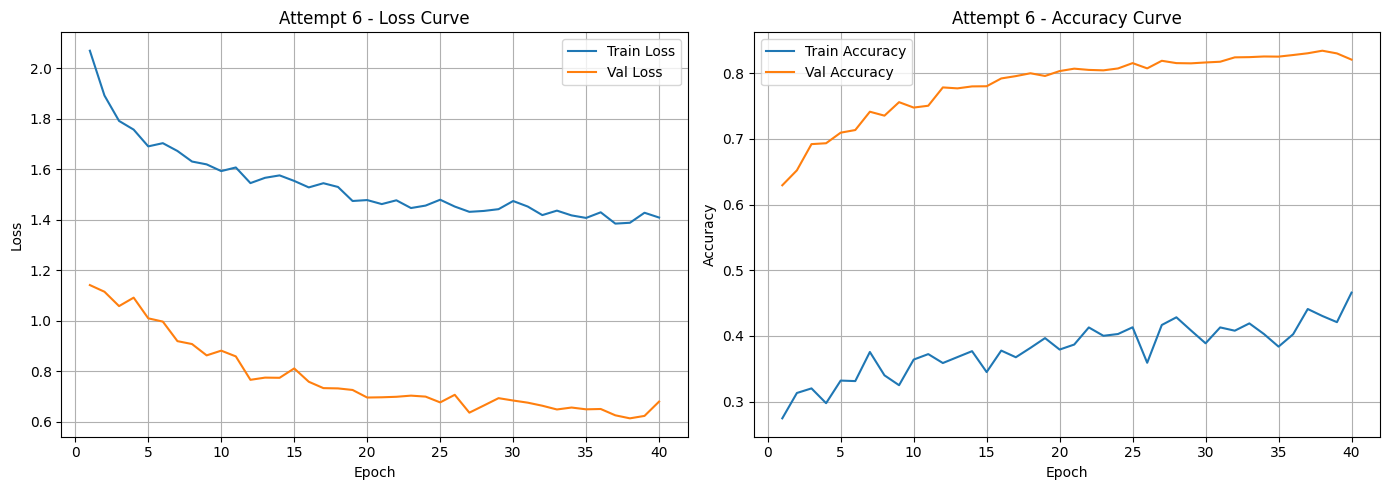

In [28]:
class StochasticSkip(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()
        self.p = p

    def forward(self, x, residual):
        if not self.training or self.p <= 0:
            return x + residual
        # drop residual with prob p
        if torch.rand(1, device=x.device).item() < self.p:
            return x
        return x + residual

class DeepMLP_Skip(nn.Module):
    def __init__(self, input_dim=784, num_classes=15, width=320, depth=10, dropout=0.15, skip_p=0.12):
        super().__init__()
        self.inp = nn.Linear(input_dim, width)
        self.blocks = nn.ModuleList()
        self.skips = nn.ModuleList()
        for _ in range(depth):
            self.blocks.append(nn.Sequential(
                nn.BatchNorm1d(width),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(width, width),
            ))
            self.skips.append(StochasticSkip(p=skip_p))
        self.head = nn.Linear(width, num_classes)

    def forward(self, x):
        x = self.inp(x)
        for blk, sk in zip(self.blocks, self.skips):
            res = blk(x)
            x = sk(x, res)
        return self.head(x)

mC5 = DeepMLP_Skip(input_dim=input_dim, num_classes=num_classes, width=320, depth=10, dropout=0.14, skip_p=0.12)
print("C5 params:", count_params(mC5))

mC5_trained, hist_C5 = fit_champion_swa(
    mC5, train_loader, val_loader,
    epochs=40, lr=2.0e-3, weight_decay=3e-4,
    label_smoothing=0.10, mixup_alpha=0.25,
    grad_clip=1.0, swa_start=0.65
)
print("C5 val acc:", evaluate(mC5_trained, val_loader)[1])
summarize_run("Attempt 6", mC5_trained, hist_C5)

In [48]:
save_model_and_history(mC5_trained, hist_C5, "mc5_trained")

Saved: mc5_trained


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


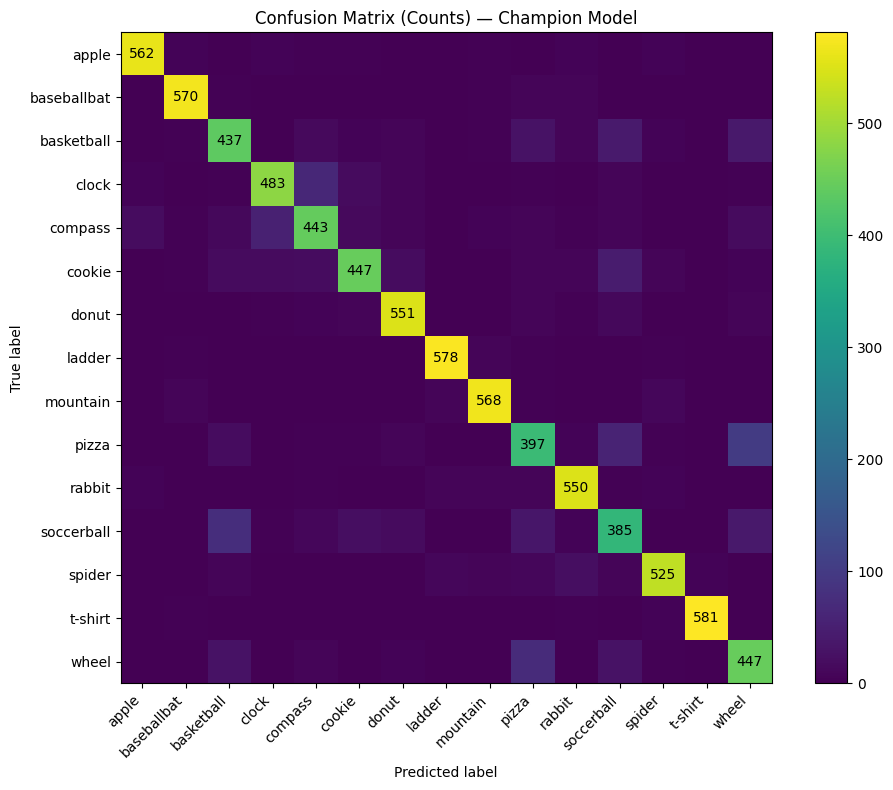

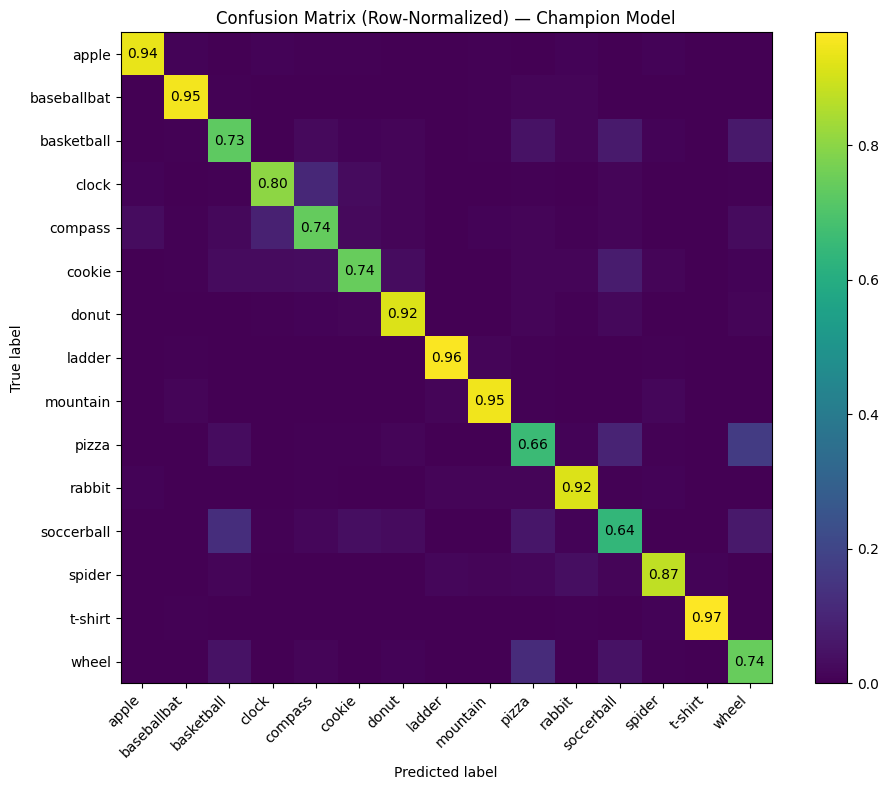


Top-2 most confused (True → Pred) pairs:
  pizza → wheel : 100 samples
  soccerball → basketball : 75 samples

=== Pair: pizza (true) → wheel (pred) ===
Misclassified count: 100
Correct pizza count: 397
Correct wheel count: 447


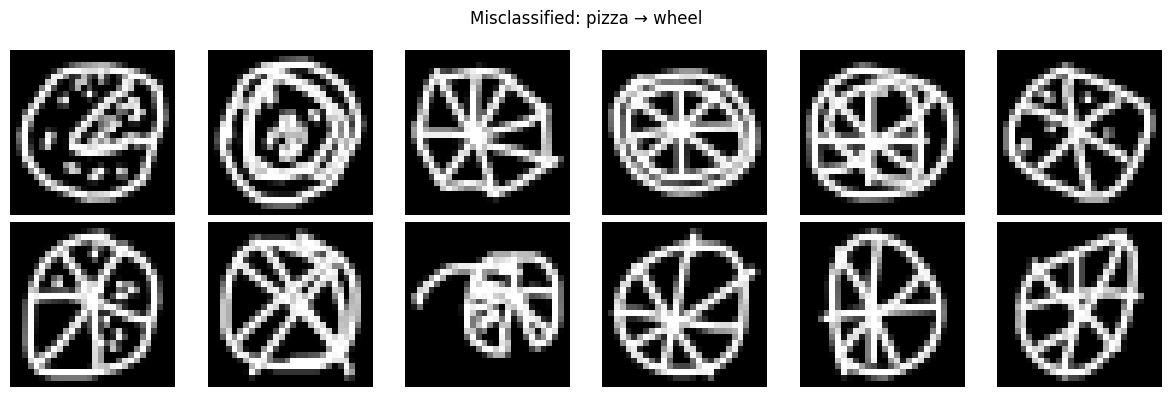

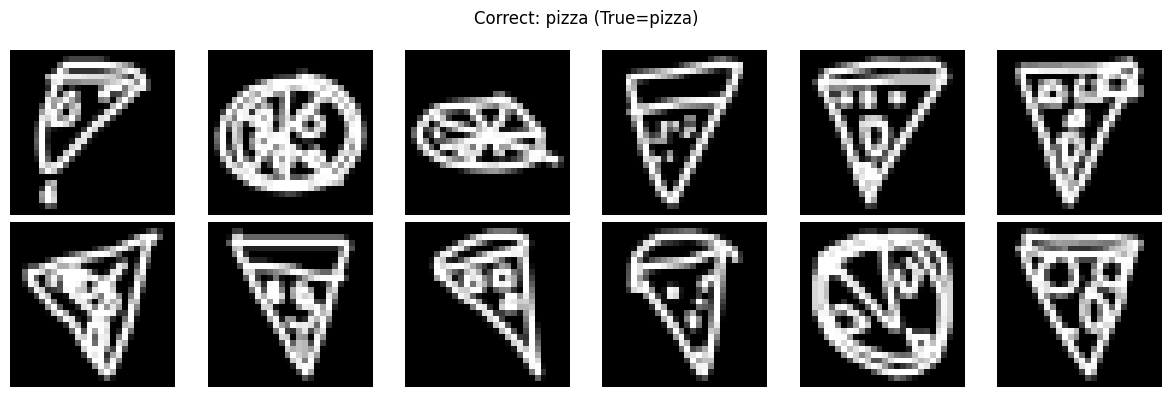

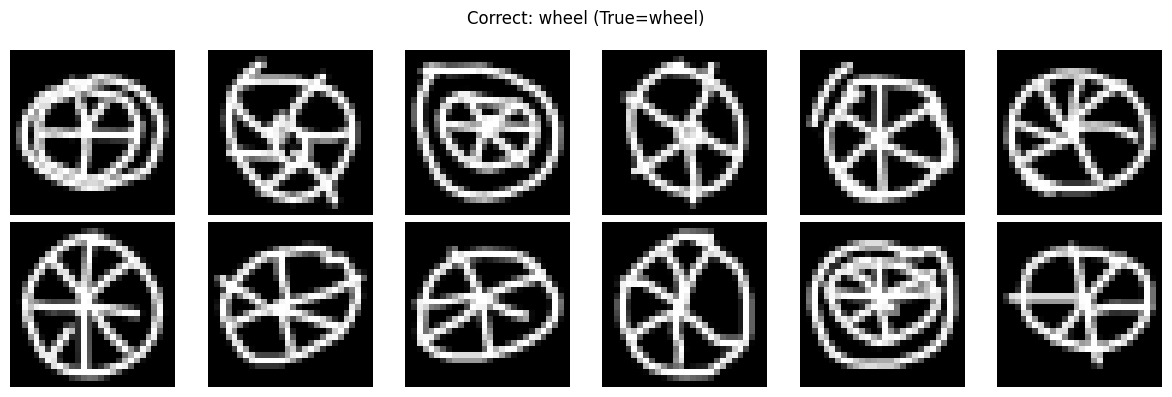


=== Pair: soccerball (true) → basketball (pred) ===
Misclassified count: 75
Correct soccerball count: 385
Correct basketball count: 437


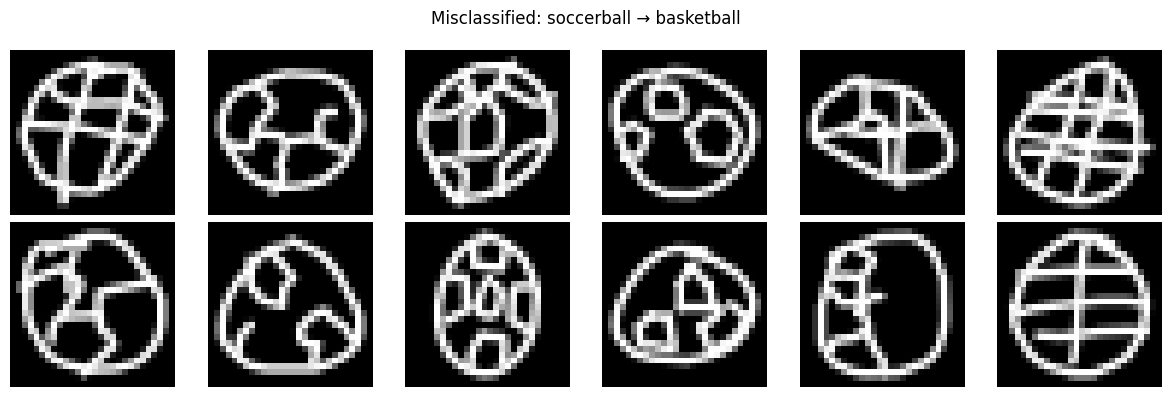

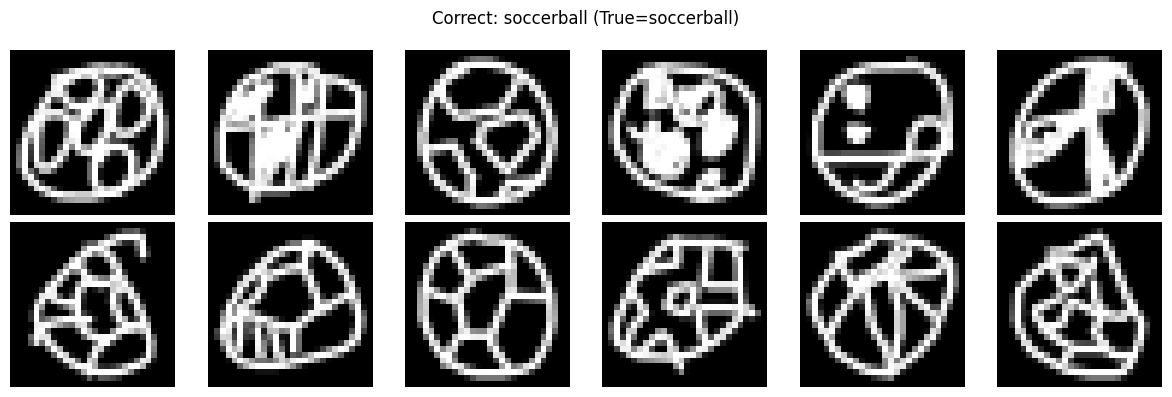

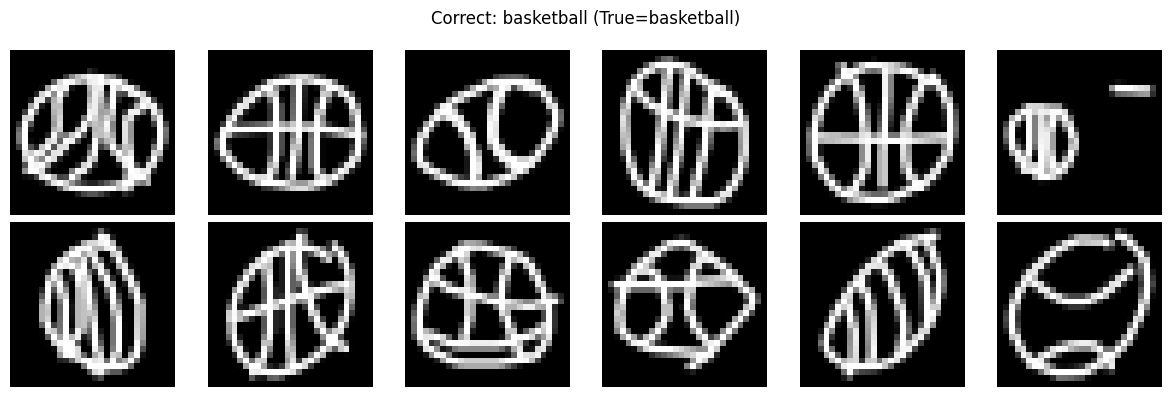


How to decide: model limitation vs data ambiguity
• If the misclassified drawings look genuinely similar/overlapping (even to you), that's likely aleatoric uncertainty (data ambiguity).
• If they look clearly different but the model still confuses them, that's more likely model limitation (underfitting / insufficient features).
• Also check if confusion persists even for 'clean' examples; persistent confusion suggests model limitation.


In [49]:
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    class_names
    assert len(class_names) == num_classes
except:
    class_names = [f"Class_{i}" for i in range(num_classes)]
    print("WARNING: class_names not found; using placeholders Class_0..Class_14.")
    print("Replace class_names with the actual 15 QuickDraw class names for your report.")

@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    all_preds, all_true = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

y_true, y_pred = get_preds(mC5_trained, val_loader)

cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

def plot_confusion_matrix(cm_show, title, is_normalized=False):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_show, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(num_classes)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = cm_show.max() * 0.65
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_show[i, j]
            if is_normalized:
                txt = f"{val:.2f}"
            else:
                txt = str(int(val))
            if i == j or val > thresh:
                plt.text(j, i, txt, ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, "Confusion Matrix (Counts) — Champion Model", is_normalized=False)
plot_confusion_matrix(cm_norm, "Confusion Matrix (Row-Normalized) — Champion Model", is_normalized=True)

off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)

flat_idx = np.argsort(off_diag.ravel())[::-1]
top_pairs = []
seen = set()
for idx in flat_idx:
    i = idx // num_classes
    j = idx % num_classes
    if off_diag[i, j] == 0:
        break
    key = (i, j)
    if key not in seen:
        top_pairs.append((i, j, off_diag[i, j]))
        seen.add(key)
    if len(top_pairs) == 2:
        break

print("\nTop-2 most confused (True → Pred) pairs:")
for (i, j, cnt) in top_pairs:
    print(f"  {class_names[i]} → {class_names[j]} : {cnt} samples")

def show_examples_for_pair(class_i, class_j, n_show=12):
    idx_mis = np.where((y_true == class_i) & (y_pred == class_j))[0]
    idx_i_ok = np.where((y_true == class_i) & (y_pred == class_i))[0]
    idx_j_ok = np.where((y_true == class_j) & (y_pred == class_j))[0]

    print(f"\n=== Pair: {class_names[class_i]} (true) → {class_names[class_j]} (pred) ===")
    print(f"Misclassified count: {len(idx_mis)}")
    print(f"Correct {class_names[class_i]} count: {len(idx_i_ok)}")
    print(f"Correct {class_names[class_j]} count: {len(idx_j_ok)}")

    def plot_grid(idxs, title):
        if len(idxs) == 0:
            print(f"  No samples for: {title}")
            return
        take = idxs[:n_show]
        cols = 6
        rows = int(np.ceil(len(take)/cols))
        plt.figure(figsize=(cols*2, rows*2))
        for k, ix in enumerate(take):
            plt.subplot(rows, cols, k+1)
            img = x_val[ix].reshape(28,28)
            plt.imshow(img, cmap="gray")
            plt.axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    rng = np.random.default_rng(42)
    rng.shuffle(idx_mis)
    rng.shuffle(idx_i_ok)
    rng.shuffle(idx_j_ok)

    plot_grid(idx_mis, f"Misclassified: {class_names[class_i]} → {class_names[class_j]}")
    plot_grid(idx_i_ok, f"Correct: {class_names[class_i]} (True={class_names[class_i]})")
    plot_grid(idx_j_ok, f"Correct: {class_names[class_j]} (True={class_names[class_j]})")

for (i, j, _) in top_pairs:
    show_examples_for_pair(i, j, n_show=12)

In [52]:
import numpy as np
import torch
test_data = test_npz
print("Available keys in test file:", test_data.files)
x_test = test_data[test_data.files[0]]
x_test = x_test.astype(np.float32) / 255.0
x_test = x_test.reshape(len(x_test), -1)

print("Test shape:", x_test.shape)
test_tensor = torch.tensor(x_test, dtype=torch.float32)

test_loader = torch.utils.data.DataLoader(
    test_tensor,
    batch_size=512,
    shuffle=False
)
mC5_trained.eval()
predictions = []

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        logits = mC5_trained(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        predictions.extend(preds)

predictions = np.array(predictions)

print("Total predictions:", len(predictions))
csv_output = ",".join(map(str, predictions))
print(csv_output)
with open("test_predictions.csv", "w") as f:
    f.write(csv_output)

print("\nSaved to test_predictions.csv")

Available keys in test file: ['test_images']
Test shape: (15000, 784)
Total predictions: 15000

=== COPY THIS LINE FOR SUBMISSION ===

6,11,5,6,0,1,11,9,14,8,9,7,5,11,13,8,13,12,11,5,13,6,9,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,6,9,10,1,5,11,0,9,5,11,6,6,10,9,9,6,7,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,14,6,0,7,1,11,5,6,3,12,9,10,14,12,1,4,5,9,7,4,14,5,9,1,1,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,6,0,8,14,11,5,12,7,13,9,2,1,9,1,12,7,4,3,0,4,14,1,9,6,8,0,4,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,14,7,11,2,13,10,3,12,3,8,6,2,1,9,14,8,6,0,4,1,5,6,10,5,14,10,1,13,1,1,10,5,7,14,5,1,11,6,2,6,3,8,1,1,4,7,7,9,6,13,14,4,0,9,6,4,5,1,3,10,0,11,4,9,11,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,11,2,3,0,7,12,8,6,6,1,7,12,12,0,3,14,4,12,4,6,6,2,0,9,12,9,6,3,8,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,13,12,6,4,14,14,7,8,10,1,11,10,9,1,10,14,12,14,0,7,7,0,12,7,6,7,12,1,7,12,11,13,4,6,5,14,11,8,7,11,12,1